# BTCUSDT Spot Trend Following Strategy — Backtest

Strategy spec: `docs/spot-trend-following-bot-btcusdt.md`

**Parameters**
- Timeframe: 4H
- Long only, one trade at a time
- Risk: $10 per trade

**Indicators:** EMA50, EMA200, ADX(14), ATR(14), RSI(14)

In [ ]:
import requests
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timezone
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

## 1. Fetch Historical Data (5+ years)

Binance limits klines to 1000 per request. We paginate backwards from today using `startTime`.

In [39]:
from datetime import datetime, timezone

def fetch_all_klines(symbol='BTCUSDT', interval='4h', years_back=5.5):
    url = 'https://api.binance.com/api/v3/klines'
    
    now = datetime.now(timezone.utc)
    start = int(now.timestamp() * 1000) - int(years_back * 365.25 * 24 * 3600 * 1000)
    
    all_data = []
    while True:
        params = {'symbol': symbol, 'interval': interval, 'limit': 1000, 'startTime': start}
        resp = requests.get(url, params=params, timeout=15)
        resp.raise_for_status()
        data = resp.json()
        if not data:
            break
        all_data.extend(data)
        start = data[-1][0] + 1  # next batch after last candle
        print(f'Fetched {len(data)} candles, total: {len(all_data)}')
    
    df = pd.DataFrame(all_data, columns=[
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_vol', 'trades',
        'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = df[col].astype(float)
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
    return df

df = fetch_all_klines()
print(f'\nTotal candles: {len(df)}')
print(f'Date range: {df["open_time"].iloc[0]} to {df["open_time"].iloc[-1]}')
df[['open_time', 'open', 'high', 'low', 'close', 'volume']].head()

Fetched 1000 candles, total: 1000
Fetched 1000 candles, total: 2000
Fetched 1000 candles, total: 3000
Fetched 1000 candles, total: 4000
Fetched 1000 candles, total: 5000
Fetched 1000 candles, total: 6000
Fetched 1000 candles, total: 7000
Fetched 1000 candles, total: 8000
Fetched 1000 candles, total: 9000
Fetched 1000 candles, total: 10000
Fetched 1000 candles, total: 11000
Fetched 1000 candles, total: 12000
Fetched 54 candles, total: 12054

Total candles: 12054
Date range: 2021-01-07 00:00:00 to 2026-07-08 20:00:00


,open_time,open,high,low,close,volume
0,2021-01-07 00:00:00,36769.36,37699.00,36422.71,37454.48,19662.246626
1,2021-01-07 04:00:00,37452.62,37700.80,36710.00,36859.85,16315.182158
2,2021-01-07 08:00:00,36863.04,37913.72,36300.00,37822.09,17213.968918
3,2021-01-07 12:00:00,37825.64,38970.42,37518.00,38970.42,22645.701477
4,2021-01-07 16:00:00,38970.41,40365.00,36500.00,39062.00,39368.560182


## 2. Indicator Calculations

In [ ]:
def calc_ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = (-delta.where(delta < 0, 0.0))
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def calc_adx(df, period=14):
    high, low, close = df['high'], df['low'], df['close']
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    up_move = high - high.shift(1)
    down_move = low.shift(1) - low
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
    alpha = 1 / period
    tr_smooth = tr.ewm(alpha=alpha, adjust=False).mean()
    plus_dm_smooth = pd.Series(plus_dm, index=df.index).ewm(alpha=alpha, adjust=False).mean()
    minus_dm_smooth = pd.Series(minus_dm, index=df.index).ewm(alpha=alpha, adjust=False).mean()
    plus_di = 100 * plus_dm_smooth / tr_smooth
    minus_di = 100 * minus_dm_smooth / tr_smooth
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=alpha, adjust=False).mean()
    return adx, plus_di, minus_di

def calc_atr(df, period=14):
    high, low, close = df['high'], df['low'], df['close']
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()

In [ ]:
# Compute all indicators
df['ema50'] = calc_ema(df['close'], 50)
df['ema200'] = calc_ema(df['close'], 200)
df['rsi'] = calc_rsi(df['close'], 14)
df['atr'] = calc_atr(df, 14)
df['adx'], df['plus_di'], df['minus_di'] = calc_adx(df)
df['atr_sma50'] = df['atr'].rolling(50).mean()

# Daily data for daily trend check
daily = df.resample('D', on='open_time').agg({
    'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last'
}).dropna().copy()
daily['ema200'] = calc_ema(daily['close'], 200)
daily_ema200 = daily['ema200'].reindex(df['open_time'], method='ffill')

print('Indicators computed')
df[['open_time', 'close', 'ema50', 'ema200', 'adx', 'atr', 'rsi']].tail(5)

Indicators computed


,open_time,close,ema50,ema200,adx,atr,rsi
48194,2026-07-08 16:00:00,62113.03,62862.158031,62318.948646,32.876206,449.458656,40.697059
48195,2026-07-08 17:00:00,62104.62,62832.450657,62316.816023,32.124380,443.234466,40.575259
48196,2026-07-08 18:00:00,62185.32,62807.072984,62315.507605,31.426256,433.487004,42.357989
48197,2026-07-08 19:00:00,62277.98,62786.324239,62315.134196,30.777998,418.537218,44.419767
48198,2026-07-08 20:00:00,62257.35,62765.580152,62314.559229,30.176045,394.024560,44.042054


## 3. Backtest Engine

In [ ]:
def run_backtest(df, risk_usdt=10):
    trades = []
    in_position = False
    entry_price = 0.0
    stop_price = 0.0
    stop_breakeven = False
    trailing_active = False
    highest_close = 0.0
    total_fees = 0.0

    for i in range(200, len(df)):
        candle = df.iloc[i]
        prev = df.iloc[i - 1]
        close = candle['close']
        high = candle['high']
        low = candle['low']

        if not in_position:
            # State 1: Trend valid?
            trend_valid = (
                prev['close'] > prev['ema200']
                and prev['ema50'] > prev['ema200']
                and prev['adx'] >= 25
            )
            if not trend_valid:
                continue

            # Skip rules
            if prev['adx'] < 25 or prev['atr'] < prev['atr_sma50']:
                continue
            if prev['close'] > prev['ema50'] + 2 * prev['atr']:
                continue

            # State 2: Pullback?
            pullback = prev['low'] <= prev['ema50'] and prev['close'] > prev['ema200']
            if not pullback:
                continue

            # State 3: RSI quality
            if not (40 <= prev['rsi'] <= 60):
                continue

            # State 4: Breakout (current close > prev high AND > ema50)
            if not (close > prev['high'] and close > prev['ema50']):
                continue

            # Stop: lowest of (swing low last 20 bars, entry - 2*ATR)
            lookback_start = max(0, i - 20)
            swing_low = df.iloc[lookback_start:i]['low'].min()
            stop_candidate2 = close - 2 * prev['atr']
            stop_price = min(swing_low, stop_candidate2)

            entry_price = close
            stop_breakeven = False
            trailing_active = False
            highest_close = close
            in_position = True

            risk_per_unit = entry_price - stop_price
            quantity = risk_usdt / risk_per_unit if risk_per_unit > 0 else 0
            fee = 0.001 * entry_price * quantity

            trades.append({
                'entry_time': candle['open_time'],
                'exit_time': None,
                'side': 'BUY',
                'entry_price': entry_price,
                'exit_price': None,
                'stop_price': stop_price,
                'quantity': quantity,
                'exit_reason': None,
                'pnl_usdt': None,
                'fee': fee,
                'roi_pct': None,
            })
            total_fees += fee

        else:
            current_trade = trades[-1]
            quantity = current_trade['quantity']
            entry_price = current_trade['entry_price']
            risk_per_unit = entry_price - stop_price
            r = (close - entry_price) / risk_per_unit if risk_per_unit > 0 else 0

            highest_close = max(highest_close, high)
            atr = candle['atr'] if not pd.isna(candle['atr']) else prev['atr']

            # Exit 4: Daily trend break
            d200 = daily_ema200.iloc[i]
            if not pd.isna(d200) and close < d200:
                exit_price = close
                pnl = (exit_price - entry_price) * quantity - current_trade['fee']
                reason = 'Daily Trend Break' if exit_price >= stop_price else 'SL'
                current_trade.update({
                    'exit_time': candle['open_time'], 'exit_price': exit_price,
                    'exit_reason': reason, 'pnl_usdt': pnl,
                    'roi_pct': (exit_price - entry_price) / entry_price * 100,
                })
                in_position = False
                continue

            # Exit 3: Trend reversal
            if candle['ema50'] < candle['ema200']:
                exit_price = close
                pnl = (exit_price - entry_price) * quantity - current_trade['fee']
                current_trade.update({
                    'exit_time': candle['open_time'], 'exit_price': exit_price,
                    'exit_reason': 'Trend Reversal', 'pnl_usdt': pnl,
                    'roi_pct': (exit_price - entry_price) / entry_price * 100,
                })
                in_position = False
                continue

            # Exit 2: Trailing stop
            if trailing_active:
                trailing_stop = highest_close - 2 * atr
                if close < trailing_stop:
                    pnl = (close - entry_price) * quantity - current_trade['fee']
                    current_trade.update({
                        'exit_time': candle['open_time'], 'exit_price': close,
                        'exit_reason': 'Trailing Stop', 'pnl_usdt': pnl,
                        'roi_pct': (close - entry_price) / entry_price * 100,
                    })
                    in_position = False
                    continue

            # Exit 1: Stop loss
            if low <= stop_price:
                pnl = (stop_price - entry_price) * quantity - current_trade['fee']
                current_trade.update({
                    'exit_time': candle['open_time'], 'exit_price': stop_price,
                    'exit_reason': 'SL', 'pnl_usdt': pnl,
                    'roi_pct': (stop_price - entry_price) / entry_price * 100,
                })
                in_position = False
                continue

            # Trade management: breakeven at 1R
            if not stop_breakeven and r >= 1:
                stop_price = entry_price
                stop_breakeven = True

            # Trade management: enable trailing at 2R
            if not trailing_active and r >= 2:
                trailing_active = True
                highest_close = high

    return trades

trades = run_backtest(df)
print(f'Total trades: {len(trades)}')

Total trades: 73


## 4. Results

In [ ]:
trades_df = pd.DataFrame(trades)
trades_df = trades_df.dropna(subset=['exit_time']).reset_index(drop=True)

if len(trades_df) == 0:
    print('No trades executed.')
else:
    total_pnl = trades_df['pnl_usdt'].sum()
    wins = (trades_df['pnl_usdt'] > 0).sum()
    losses = (trades_df['pnl_usdt'] <= 0).sum()
    win_rate = wins / len(trades_df) * 100
    avg_win = trades_df.loc[trades_df['pnl_usdt'] > 0, 'pnl_usdt'].mean() if wins > 0 else 0
    avg_loss = trades_df.loc[trades_df['pnl_usdt'] <= 0, 'pnl_usdt'].mean() if losses > 0 else 0
    profit_factor = (
        trades_df.loc[trades_df['pnl_usdt'] > 0, 'pnl_usdt'].sum() /
        abs(trades_df.loc[trades_df['pnl_usdt'] <= 0, 'pnl_usdt'].sum())
    ) if losses > 0 else float('inf')
    max_dd = trades_df['pnl_usdt'].cumsum().min()

    print('=' * 50)
    print('BACKTEST RESULTS')
    print('=' * 50)
    print(f'Period:        {df["open_time"].iloc[200]:%Y-%m-%d} to {df["open_time"].iloc[-1]:%Y-%m-%d}')
    print(f'Total Trades:  {len(trades_df)}')
    print(f'Wins:          {wins}')
    print(f'Losses:        {losses}')
    print(f'Win Rate:      {win_rate:.1f}%')
    print(f'Total P&L:     ${total_pnl:.2f}')
    print(f'Avg Win:       ${avg_win:.2f}')
    print(f'Avg Loss:      ${avg_loss:.2f}')
    print(f'Profit Factor: {profit_factor:.2f}')
    print(f'Max Drawdown:  ${max_dd:.2f}')
    print()
    print('Exit Reasons:')
    print(trades_df['exit_reason'].value_counts().to_string())

trades_df[['entry_time', 'exit_time', 'entry_price', 'exit_price', 'exit_reason', 'pnl_usdt']].head(10)

BACKTEST RESULTS
Period:        2021-01-15 to 2026-07-08
Total Trades:  73
Wins:          17
Losses:        56
Win Rate:      23.3%
Total P&L:     $84.12
Avg Win:       $26.63
Avg Loss:      $-6.58
Profit Factor: 1.23
Max Drawdown:  $-157.53

Exit Reasons:
exit_reason
SL                   41
Daily Trend Break    21
Trend Reversal        8
Trailing Stop         3


,entry_time,exit_time,entry_price,exit_price,exit_reason,pnl_usdt
0,2021-02-07 07:00:00,2021-02-07 14:00:00,39030.00,38214.980000,Daily Trend Break,-7.326650
1,2021-02-07 22:00:00,2021-02-08 02:00:00,38797.02,38249.000000,Daily Trend Break,-4.058153
2,2021-02-15 10:00:00,2021-02-22 14:00:00,47849.99,47849.990000,SL,-0.209942
3,2021-03-15 01:00:00,2021-03-15 06:00:00,60066.56,58565.275792,SL,-10.400101
4,2021-04-10 23:00:00,2021-04-14 14:00:00,59769.13,62996.120000,Trailing Stop,22.711907
5,2021-04-14 16:00:00,2021-04-14 18:00:00,63484.79,61929.972821,SL,-10.408310
6,2021-04-14 21:00:00,2021-04-16 07:00:00,62773.65,61047.218003,SL,-10.363603
7,2021-05-08 17:00:00,2021-05-09 12:00:00,58898.98,56749.750000,SL,-10.274047
8,2021-08-14 14:00:00,2021-08-15 07:00:00,46900.00,45971.030000,SL,-10.504860
9,2021-08-18 16:00:00,2021-08-18 23:00:00,45878.42,44705.290000,Trend Reversal,-7.277054


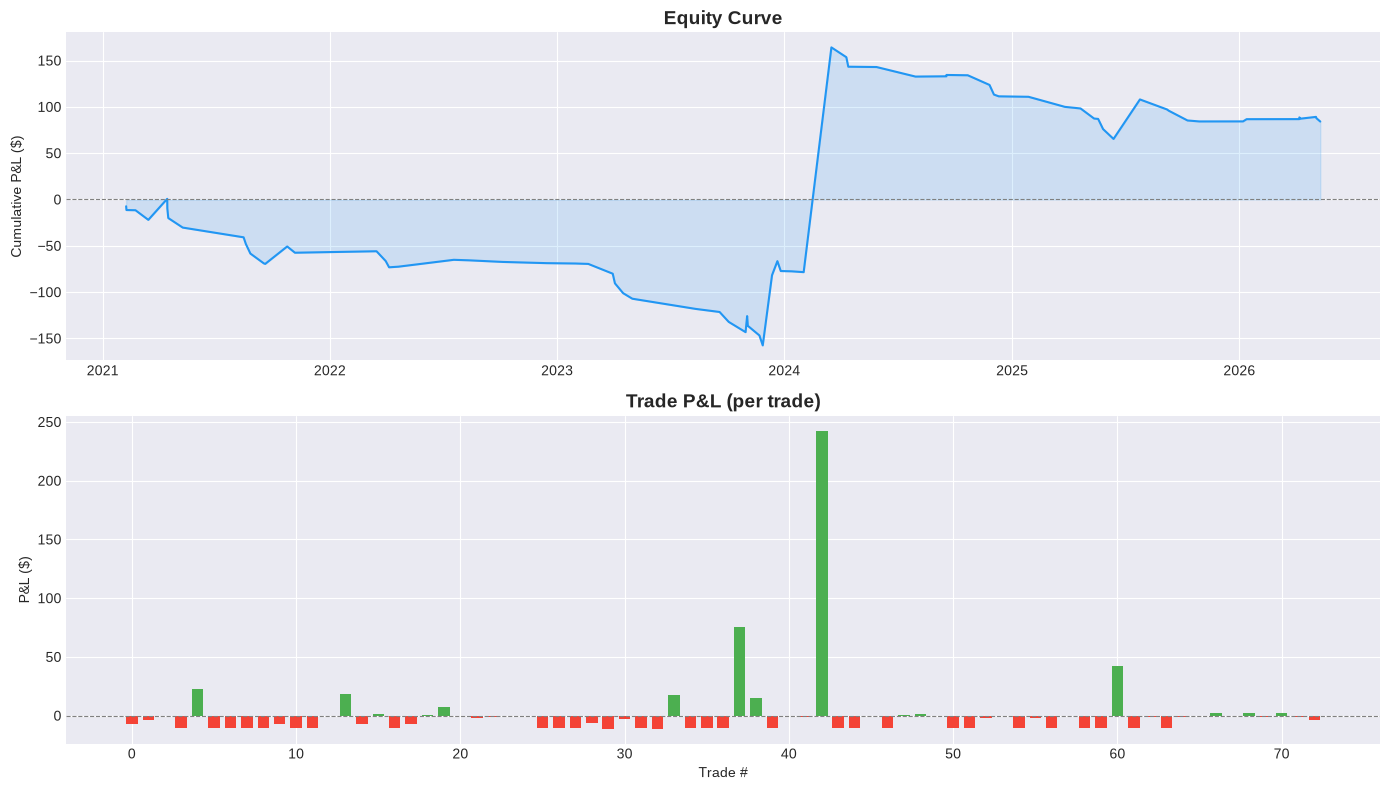

In [ ]:
if len(trades_df) > 0:
    trades_df['cumulative_pnl'] = trades_df['pnl_usdt'].cumsum()
    cum_pnl = trades_df.set_index('exit_time')['cumulative_pnl']

    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(cum_pnl.index, cum_pnl.values, linewidth=1.5, color='#2196f3')
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_title('Equity Curve', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Cumulative P&L ($)')
    axes[0].fill_between(cum_pnl.index, cum_pnl.values, 0, alpha=0.15, color='#2196f3')

    colors = ['#4caf50' if x > 0 else '#f44336' for x in trades_df['pnl_usdt']]
    axes[1].bar(range(len(trades_df)), trades_df['pnl_usdt'], color=colors, width=0.7)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_title('Trade P&L (per trade)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Trade #')
    axes[1].set_ylabel('P&L ($)')

    plt.tight_layout()
    plt.show()
else:
    print('No trades — nothing to plot.')

## 5. Trade Log

In [ ]:
if len(trades_df) > 0:
    display_df = trades_df[[
        'entry_time', 'exit_time', 'side', 'entry_price', 'exit_price',
        'stop_price', 'exit_reason', 'pnl_usdt', 'roi_pct'
    ]].copy()
    display_df['pnl_usdt'] = display_df['pnl_usdt'].round(2)
    display_df['roi_pct'] = display_df['roi_pct'].round(2)
    display_df
else:
    print('No trades.')